In [34]:
import pandas as pd

datapath = 'deepseek_generated_full_data.csv'
df = pd.read_csv(datapath)
df.head()

,Unnamed: 0,class,comment,full_class,subclass
0,0,1,The infection curve is too steep; real-world t...,1.1,1
1,1,1,The peak is too narrow—superspreading events w...,1.1,1
2,2,1,The decline post-peak is too abrupt; residual ...,1.1,1
3,3,1,"The curve assumes uniform transmission, but he...",1.1,1
4,4,1,The initial growth rate is implausibly high gi...,1.1,1


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2111 non-null   int64  
 1   class       2111 non-null   int64  
 2   comment     2111 non-null   object 
 3   full_class  2111 non-null   float64
 4   subclass    2111 non-null   int64  
 5   labels      2111 non-null   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 99.1+ KB


In [35]:
df['labels'] = df['full_class'].astype(str).str.replace(".", "")

In [36]:
df['labels'].unique()

array(['11', '12', '13', '14', '21', '22', '23', '31', '32', '41', '42'],
      dtype=object)

In [37]:
import torch
import numpy as np
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-cased')
labels_level1 = {1: 0,
                 2: 5,
                 3: 9,
                 4: 12
                 }
labels_level1_contain = {0: [0, 1, 2, 3],
                         1: [4, 5, 6],
                         2: [7, 8],
                         3: [9, 10]
                         }
labels_level2 = {'11': 0,
                 '12': 1,
                 '13': 2,
                 '14': 3,
                 '21': 4,
                 '22': 5,
                 '23': 6,
                 '31': 7,
                 '32': 8,
                 '41': 9,
                 '42': 10
                 }

labels_level_main = {'1': 0,
                     '11': 1,
                     '12': 2,
                     '13': 3,
                     '14': 4,
                     '2': 5,
                     '21': 6,
                     '22': 7,
                     '23': 8,
                     '3': 9,
                     '31': 10,
                     '32': 11,
                     '4': 12,
                     '41': 13,
                     '42': 14
                     }

hierarchy = [(0, 1),
             (0, 2),
             (0, 3),
             (0, 4),
             (5, 6),
             (5, 7),
             (5, 8),
             (9, 10),
             (9, 11),
             (12, 13),
             (12, 14),]


class Dataset(torch.utils.data.Dataset):

    def __init__(self, df):

        self.labels_level1 = [labels_level1[label] for label in df['class']]
        self.labels_level2 = [labels_level_main[label]
                              for label in df['labels']]
        self.hierarchy = hierarchy
        self.texts = [tokenizer(text,
                                padding='max_length', max_length=32, truncation=True,
                                return_tensors="pt") for text in df['comment']]

    def classes(self):
        return self.labels_level2

    def __len__(self):
        return len(self.labels_level2)

    def get_batch_labels(self, idx):
        arr = torch.zeros(15)
        arr[self.labels_level1[idx]] = 1
        arr[self.labels_level2[idx]] = 1
        # print(arr)
        return arr

    def get_batch_texts(self, idx):
        # Fetch a batch of inputs
        return self.texts[idx]

    def __getitem__(self, idx):

        batch_texts = self.get_batch_texts(idx)
        batch_y = self.get_batch_labels(idx)
        return batch_texts, batch_y

In [38]:
from sklearn.model_selection import train_test_split

# First split: 60% train, 40% temp
df_train, df_temp = train_test_split(df, test_size=0.4, random_state=42, )

# Second split: 50% of temp for val and test (which is 20% of original)
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=42)

print(len(df_train), len(df_val), len(df_test))

1266 422 423


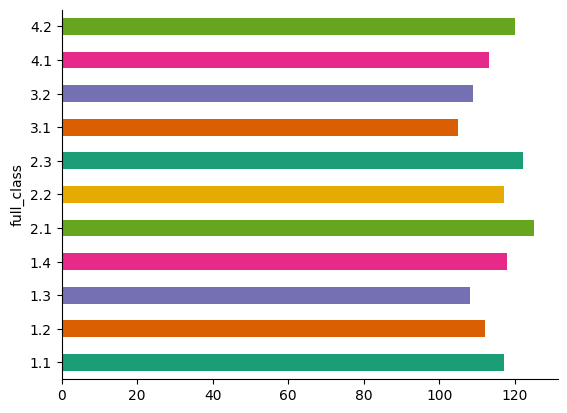

In [55]:
from matplotlib import pyplot as plt
import seaborn as sns

df_train.groupby('full_class').size().plot(
    kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

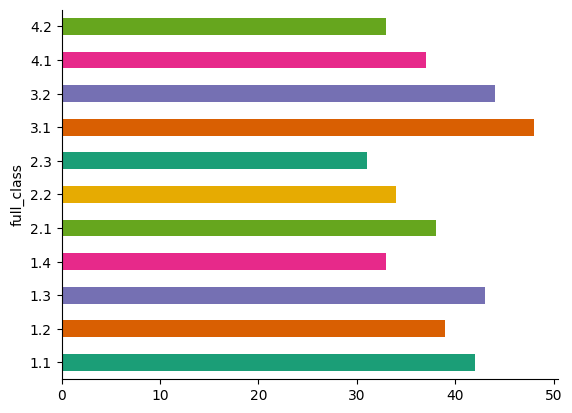

In [46]:
df_val.groupby('full_class').size().plot(
    kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

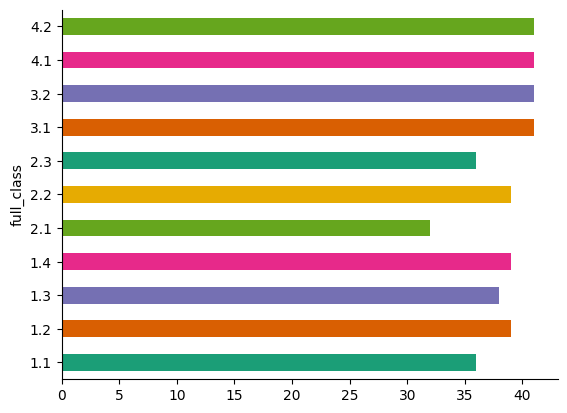

In [47]:
df_test.groupby('full_class').size().plot(
    kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [39]:
from torch import nn
from transformers import BertModel
from huggingface_hub import PyTorchModelHubMixin


class BertClassifier(nn.Module, PyTorchModelHubMixin):

    def __init__(self, dropout=0.5):

        super(BertClassifier, self).__init__()

        self.bert = BertModel.from_pretrained('bert-base-cased')
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(768, 15)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_id, mask):

        _, pooled_output = self.bert(
            input_ids=input_id, attention_mask=mask, return_dict=False)
        dropout_output = self.dropout(pooled_output)
        linear_output = self.linear(dropout_output)
        final_layer = self.sigmoid(linear_output)

        return final_layer

In [48]:
from huggingface_hub import PyTorchModelHubMixin, notebook_login

# notebook_login()

In [40]:
# model = BertClassifier()

# model.save_pretrained("epidemic_classificator_model")

# model.push_to_hub("epidemic_classificator_model")

model = BertClassifier.from_pretrained(
    "Dinara777/epidemic_classificator_model")

In [ ]:
from torch.optim import Adam, AdamW
from tqdm import tqdm
from optimizers import DenseSparseAdam


def train(model, train_data, val_data, learning_rate, epochs):

    batch_size = 8

    train, val = Dataset(train_data), Dataset(val_data)

    train_dataloader = torch.utils.data.DataLoader(
        train, batch_size=batch_size, shuffle=True)
    val_dataloader = torch.utils.data.DataLoader(val, batch_size=batch_size)

    use_cuda = torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")

    criterion = nn.BCELoss()
    optimizer = AdamW(model.parameters(), lr=learning_rate)

    if use_cuda:

        model = model.cuda()
        criterion = criterion.cuda()

    for epoch_num in range(epochs):

        total_acc_train = 0
        total_loss_train = 0
        for train_input, train_label in tqdm(train_dataloader):

            train_label = train_label.to(device)
            mask = train_input['attention_mask'].to(device)
            input_id = train_input['input_ids'].squeeze(1).to(device)

            output = model(input_id, mask)
            tmp_mask = torch.ones_like(output)
            tmp_mask[:, [0, 5, 9, 12]] = 0
            # print(train_label)
            # print(output)
            # break
            regs = torch.zeros(len(output), len(hierarchy)).to(device)
            for idx, tup in enumerate(hierarchy):
                p = tup[0]
                c = tup[1]
                regs[:, idx] = output[:, c] - output[:, p]

            # print(output)
            # print(regs)
            # break
            batch_loss = criterion(output, train_label)
            batch_loss += 0.01 * torch.sum(nn.functional.relu(regs)).item()
            total_loss_train += batch_loss.item()

            output = tmp_mask*output
            train_label = tmp_mask * train_label
            # print(output.argmax(dim=1))
            # print(train_label.argmax(dim=1))
            acc = (output.argmax(dim=1) ==
                   train_label.argmax(dim=1)).sum().item()
            total_acc_train += acc
            # break
            model.zero_grad()
            batch_loss.backward()
            optimizer.step()

        total_acc_val = 0
        total_loss_val = 0

        with torch.no_grad():

            for val_input, val_label in val_dataloader:

                val_label = val_label.to(device)
                mask = val_input['attention_mask'].to(device)
                input_id = val_input['input_ids'].squeeze(1).to(device)

                output = model(input_id, mask)

                batch_loss = criterion(output, val_label)
                total_loss_val += batch_loss.item()
                tmp_mask = torch.ones_like(output)
                tmp_mask[:, [0, 5, 9, 12]] = 0
                output = tmp_mask*output
                val_label = tmp_mask * val_label
                acc = (output.argmax(dim=1) ==
                       val_label.argmax(dim=1)).sum().item()
                total_acc_val += acc

        print(
            f'Epochs: {epoch_num + 1} | Train Loss: {total_loss_train / len(train_data): .3f} \
                | Train Accuracy: {total_acc_train / len(train_data): .3f} \
                | Val Loss: {total_loss_val / len(val_data): .3f} \
                | Val Accuracy: {total_acc_val / len(val_data): .3f}')

100%|██████████| 159/159 [05:30<00:00,  2.08s/it]


Epochs: 1 | Train Loss:  0.062                 | Train Accuracy:  0.116                 | Val Loss:  0.047                 | Val Accuracy:  0.154


100%|██████████| 159/159 [04:12<00:00,  1.59s/it]


Epochs: 2 | Train Loss:  0.040                 | Train Accuracy:  0.307                 | Val Loss:  0.035                 | Val Accuracy:  0.422


100%|██████████| 159/159 [04:09<00:00,  1.57s/it]


Epochs: 3 | Train Loss:  0.030                 | Train Accuracy:  0.549                 | Val Loss:  0.029                 | Val Accuracy:  0.626


100%|██████████| 159/159 [04:06<00:00,  1.55s/it]


Epochs: 4 | Train Loss:  0.023                 | Train Accuracy:  0.796                 | Val Loss:  0.024                 | Val Accuracy:  0.765


100%|██████████| 159/159 [04:06<00:00,  1.55s/it]


Epochs: 5 | Train Loss:  0.018                 | Train Accuracy:  0.906                 | Val Loss:  0.021                 | Val Accuracy:  0.820


In [14]:
LR = 1e-6
train(model, df_train, df_val, LR, epochs=5)

100%|██████████| 159/159 [04:08<00:00,  1.56s/it]


Epochs: 1 | Train Loss:  0.014                 | Train Accuracy:  0.976                 | Val Loss:  0.019                 | Val Accuracy:  0.832


100%|██████████| 159/159 [04:12<00:00,  1.59s/it]


Epochs: 2 | Train Loss:  0.013                 | Train Accuracy:  0.983                 | Val Loss:  0.019                 | Val Accuracy:  0.829


100%|██████████| 159/159 [04:18<00:00,  1.62s/it]


Epochs: 3 | Train Loss:  0.012                 | Train Accuracy:  0.985                 | Val Loss:  0.018                 | Val Accuracy:  0.827


100%|██████████| 159/159 [04:07<00:00,  1.56s/it]


Epochs: 4 | Train Loss:  0.012                 | Train Accuracy:  0.987                 | Val Loss:  0.018                 | Val Accuracy:  0.827


100%|██████████| 159/159 [04:11<00:00,  1.58s/it]


Epochs: 5 | Train Loss:  0.011                 | Train Accuracy:  0.992                 | Val Loss:  0.018                 | Val Accuracy:  0.825


Test Accuracy: 0.820


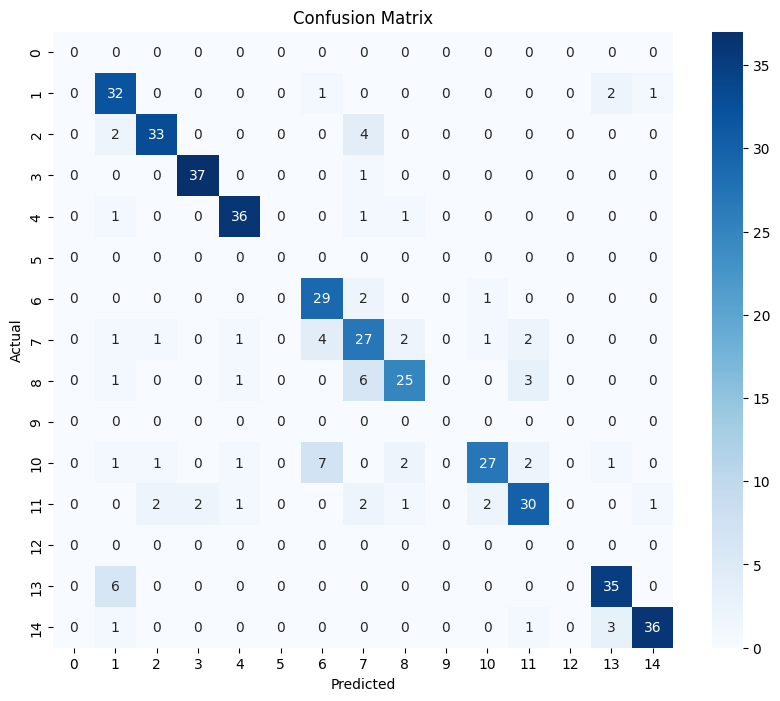

(0.8203309692671394,
 array([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0, 32,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  2,  1],
        [ 0,  2, 33,  0,  0,  0,  0,  4,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0, 37,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  1,  0,  0, 36,  0,  0,  1,  1,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0, 29,  2,  0,  0,  1,  0,  0,  0,  0],
        [ 0,  1,  1,  0,  1,  0,  4, 27,  2,  0,  1,  2,  0,  0,  0],
        [ 0,  1,  0,  0,  1,  0,  0,  6, 25,  0,  0,  3,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  1,  1,  0,  1,  0,  7,  0,  2,  0, 27,  2,  0,  1,  0],
        [ 0,  0,  2,  2,  1,  0,  0,  2,  1,  0,  2, 30,  0,  0,  1],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  6,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 35,  0],

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch


def evaluate(model, test_data, num_classes=None, plot_cm=True):
    """
    Evaluate model performance and generate confusion matrix

    Args:
        model: The model to evaluate
        test_data: Test dataset
        num_classes: Number of classes (for confusion matrix)
        plot_cm: Whether to plot the confusion matrix
    """

    batch_size = 2

    test = Dataset(test_data)
    test_dataloader = torch.utils.data.DataLoader(test, batch_size=batch_size)

    use_cuda = torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")

    if use_cuda:
        model = model.cuda()

    total_acc_test = 0
    all_preds = []
    all_labels = []

    # Create tmp_mask on the same device as the model
    tmp_mask = torch.ones((batch_size, 15), device=device)
    tmp_mask[:, [0, 5, 9, 12]] = 0

    with torch.no_grad():
        for test_input, test_label in test_dataloader:
            test_label = test_label.to(device)
            mask = test_input['attention_mask'].to(device)
            input_id = test_input['input_ids'].squeeze(1).to(device)

            output = model(input_id, mask)
            output = tmp_mask * output
            test_label = tmp_mask * test_label
            
            acc = (output.argmax(dim=1) == test_label.argmax(dim=1)).sum().item()

            _, preds = torch.max(output, dim=1)
            total_acc_test += acc
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(test_label.argmax(dim=1).cpu().numpy())

    # Calculate accuracy
    accuracy = total_acc_test / len(test_data)
    print(f'Test Accuracy: {accuracy:.3f}')

    # Generate confusion matrix
    if num_classes is not None:
        cm = confusion_matrix(all_labels, all_preds, labels=range(num_classes))

        if plot_cm:
            plt.figure(figsize=(10, 8))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=range(num_classes),
                        yticklabels=range(num_classes))
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
            plt.title('Confusion Matrix')
            plt.show()

        return accuracy, cm
    else:
        return accuracy


evaluate(model, df_test, num_classes=15)

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score


def evaluate(model, test_data, num_classes=None, plot_cm=True):
    """
    Evaluate model performance and generate confusion matrix

    Args:
        model: The model to evaluate
        test_data: Test dataset
        num_classes: Number of classes (for confusion matrix)
        plot_cm: Whether to plot the confusion matrix
    Returns:
        Dictionary containing accuracy, confusion matrix (if num_classes provided),
        micro F1 score, and macro F1 score
    """

    batch_size = 2

    test = Dataset(test_data)
    test_dataloader = torch.utils.data.DataLoader(test, batch_size=batch_size)

    use_cuda = torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")

    if use_cuda:
        model = model.cuda()

    model.eval()
    total_acc_test = 0
    all_preds = []
    all_labels = []

    tmp_mask = torch.ones((batch_size, 15))
    tmp_mask[:, [0, 5, 9, 12]] = 0

    with torch.no_grad():
        for test_input, test_label in test_dataloader:
            test_label = test_label.to(device)
            mask = test_input['attention_mask'].to(device)
            input_id = test_input['input_ids'].squeeze(1).to(device)

            output = model(input_id, mask)
            output = tmp_mask*output
            test_label = tmp_mask * test_label
            acc = (output.argmax(dim=1) ==
                   test_label.argmax(dim=1)).sum().item()

            _, preds = torch.max(output, dim=1)
            total_acc_test += acc
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(test_label.argmax(dim=1).cpu().numpy())

    # Calculate accuracy
    accuracy = total_acc_test / len(test_data)
    print(f'Test Accuracy: {accuracy:.3f}')

    # Calculate F1 scores
    micro_f1 = f1_score(all_labels, all_preds, average='micro')
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    print(f'Micro F1 Score: {micro_f1:.4f}')
    print(f'Macro F1 Score: {macro_f1:.4f}')

    results = {
        'accuracy': accuracy,
        'micro_f1': micro_f1,
        'macro_f1': macro_f1
    }

    # Generate confusion matrix
    if num_classes is not None:
        cm = confusion_matrix(all_labels, all_preds, labels=range(num_classes))
        results['confusion_matrix'] = cm

        if plot_cm:
            plt.figure(figsize=(10, 8))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=range(num_classes),
                        yticklabels=range(num_classes))
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
            plt.title('Confusion Matrix')
            plt.show()

    return results


# Example usage
evaluation_results = evaluate(model, df_test, num_classes=15)

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [28]:
evaluation_results

{'accuracy': 0.8203309692671394,
 'micro_f1': 0.8183962264150944,
 'macro_f1': 0.8187601274336909,
 'confusion_matrix': array([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0, 31,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  3,  1],
        [ 0,  2, 31,  0,  2,  0,  0,  4,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0, 37,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  1, 35,  0,  0,  2,  0,  0,  1,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0, 26,  4,  0,  0,  2,  0,  0,  0,  0],
        [ 0,  1,  1,  0,  0,  0,  2, 32,  1,  0,  1,  1,  0,  0,  0],
        [ 0,  1,  0,  0,  1,  0,  0,  8, 24,  0,  0,  2,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  2,  0,  0,  0,  0,  6,  0,  2,  0, 30,  1,  0,  1,  0],
        [ 0,  0,  2,  2,  1,  0,  0,  2,  1,  0,  3, 29,  0,  0,  1],
        [ 0,  0,  0,  0,  0,  0,  0,  0, 

In [24]:
# 1. First save ONLY the state_dict (best practice)
# torch.save(model.state_dict(),
#            'saved_models/model_weights_MATCH_LOSS_2_82_0.pth')

# # 2. When loading:
model = model = BertClassifier()
state_dict = torch.load(
    'saved_models/model_weights_MATCH_LOSS_2_82_0.pth', weights_only=True)
model.load_state_dict(state_dict)

<All keys matched successfully>

In [28]:
df

,Unnamed: 0,class,comment,full_class,subclass,labels
0,0,1,The infection curve is too steep; real-world t...,1.1,1,11
1,1,1,The peak is too narrow—superspreading events w...,1.1,1,11
2,2,1,The decline post-peak is too abrupt; residual ...,1.1,1,11
3,3,1,"The curve assumes uniform transmission, but he...",1.1,1,11
4,4,1,The initial growth rate is implausibly high gi...,1.1,1,11
...,...,...,...,...,...,...
2106,105,4,Pediatric cases at peak are underestimated by ...,4.2,2,42
2107,106,4,Peak transmission occurs in unvaccinated cohor...,4.2,2,42
2108,107,4,Peak wastewater viral load corresponds to high...,4.2,2,42
2109,108,4,The model ignores nursing home outbreaks infla...,4.2,2,42


Accuracy: 0.8109
Micro F1: 0.8511
Macro F1: 0.8365
Micro Precision: 0.8511
Macro Precision: 0.8469
Micro Recall: 0.8511
Macro Recall: 0.8323


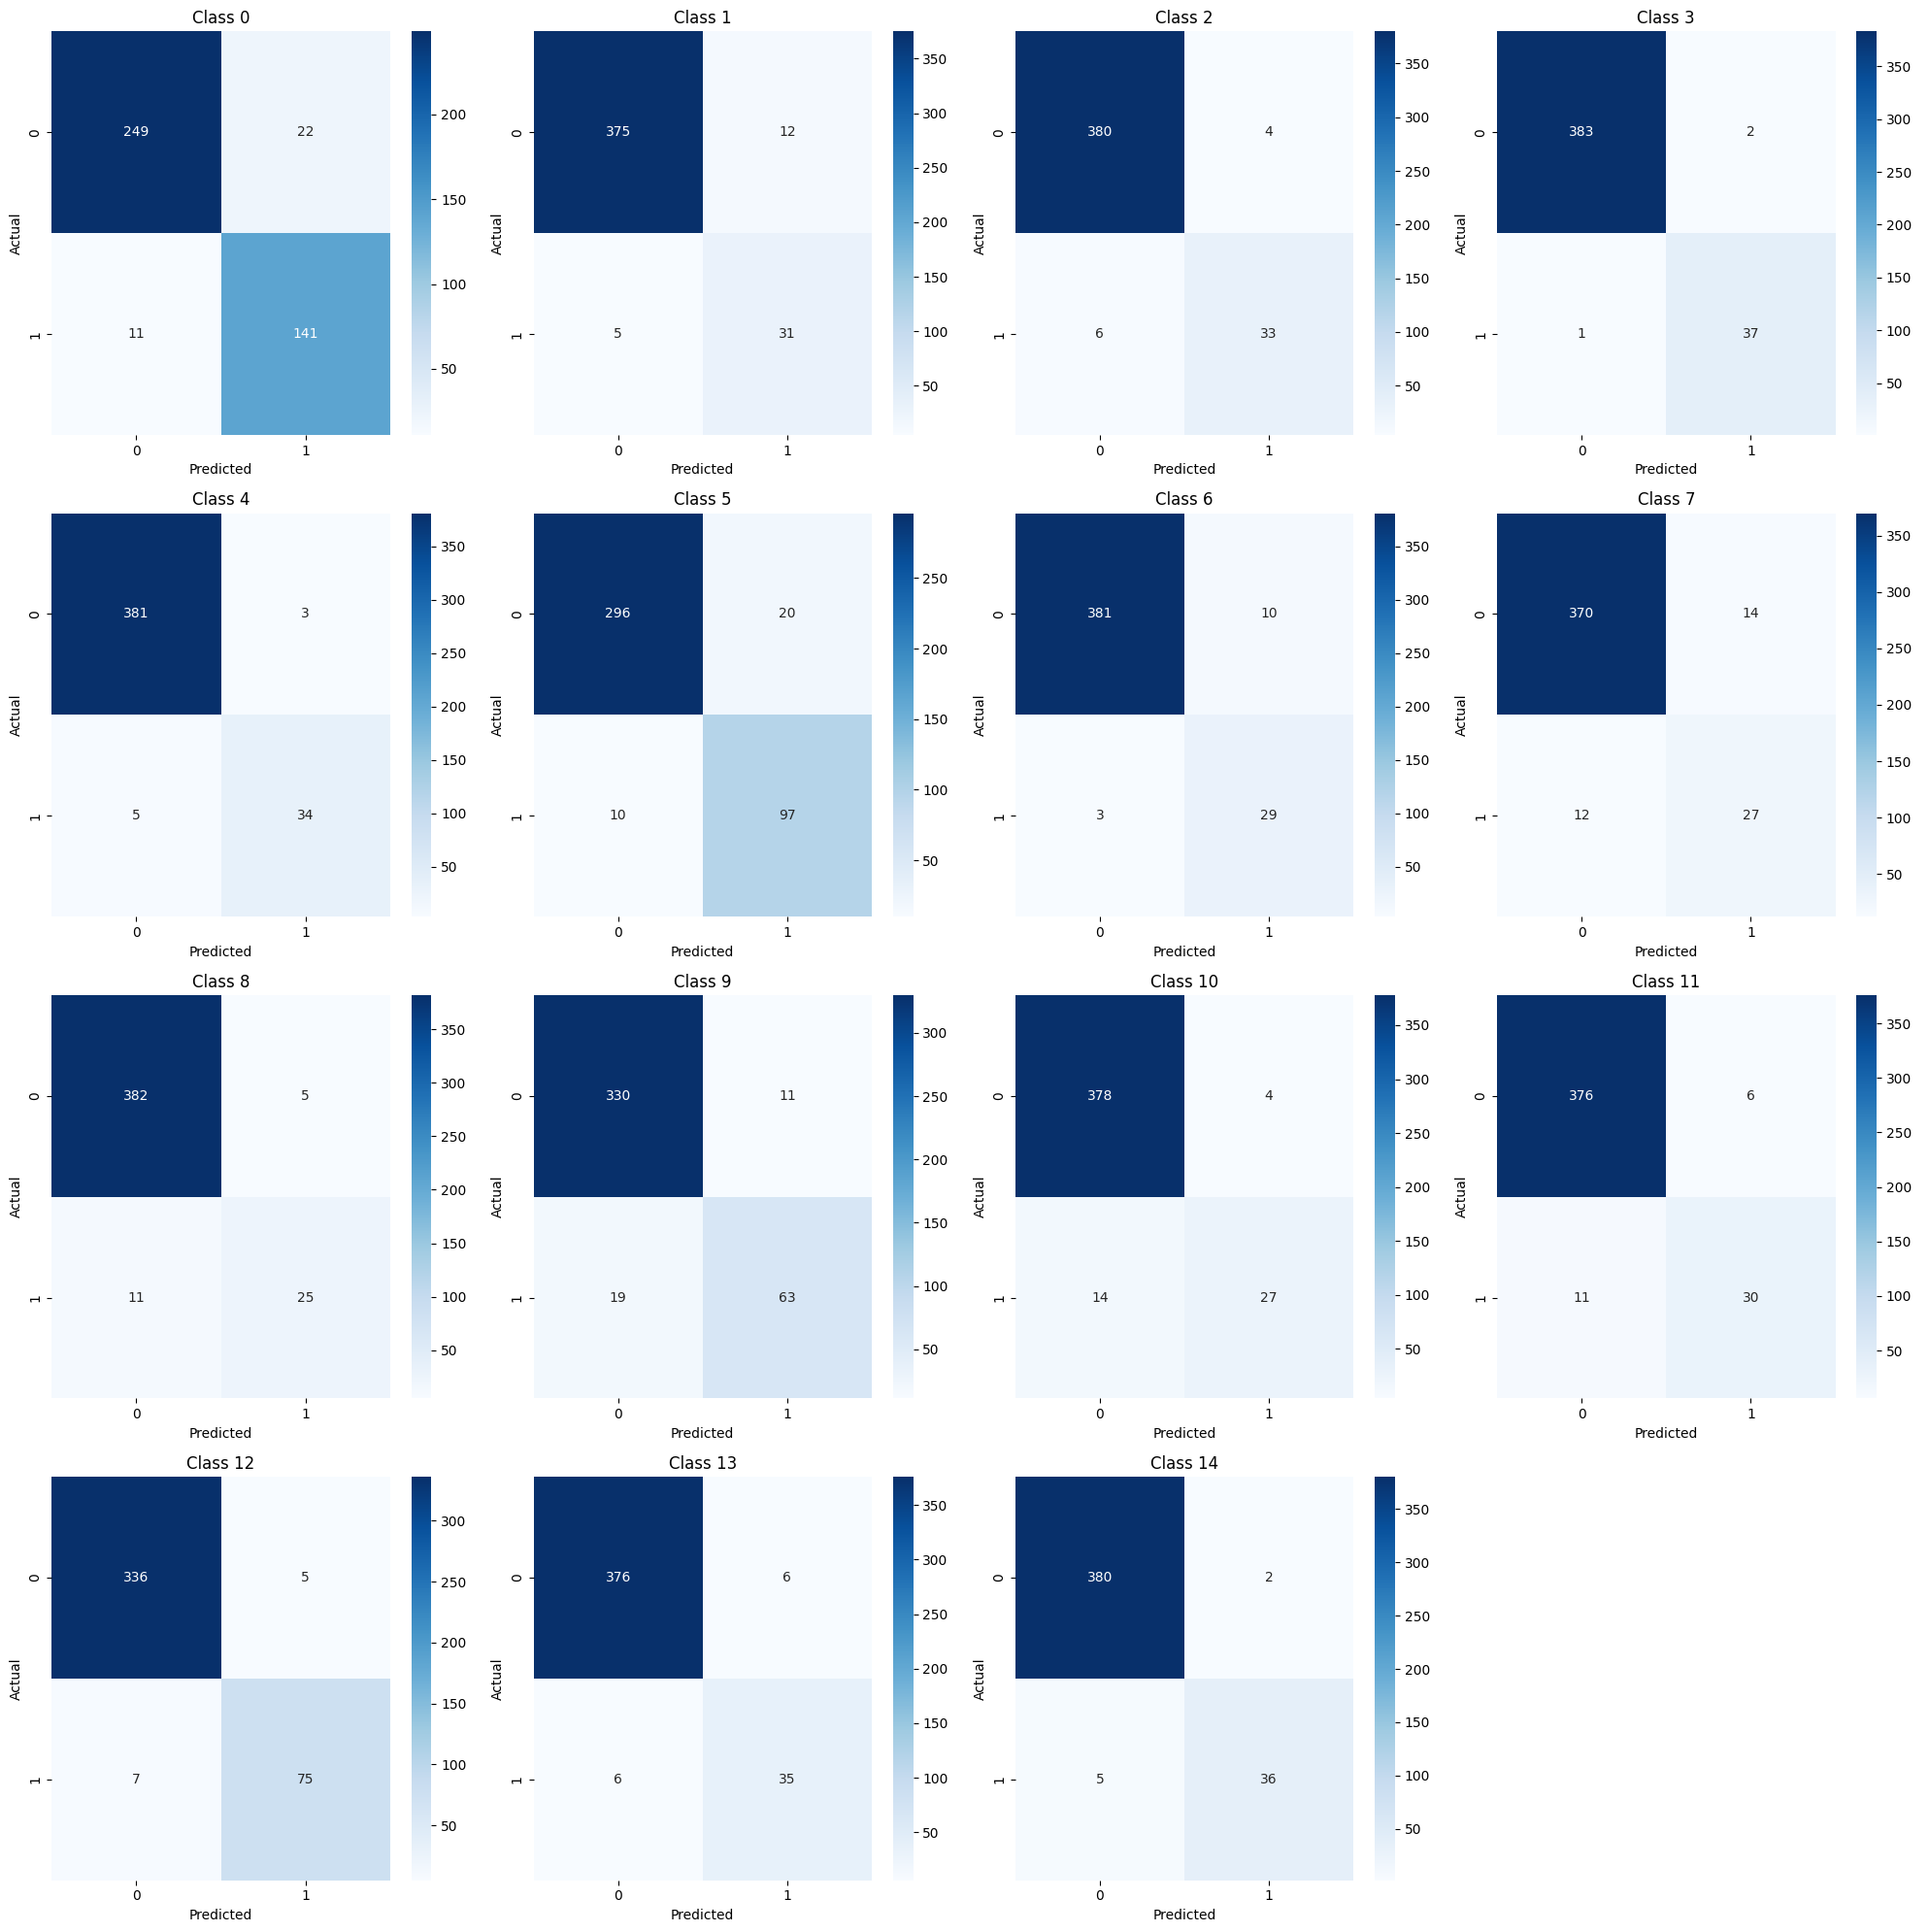

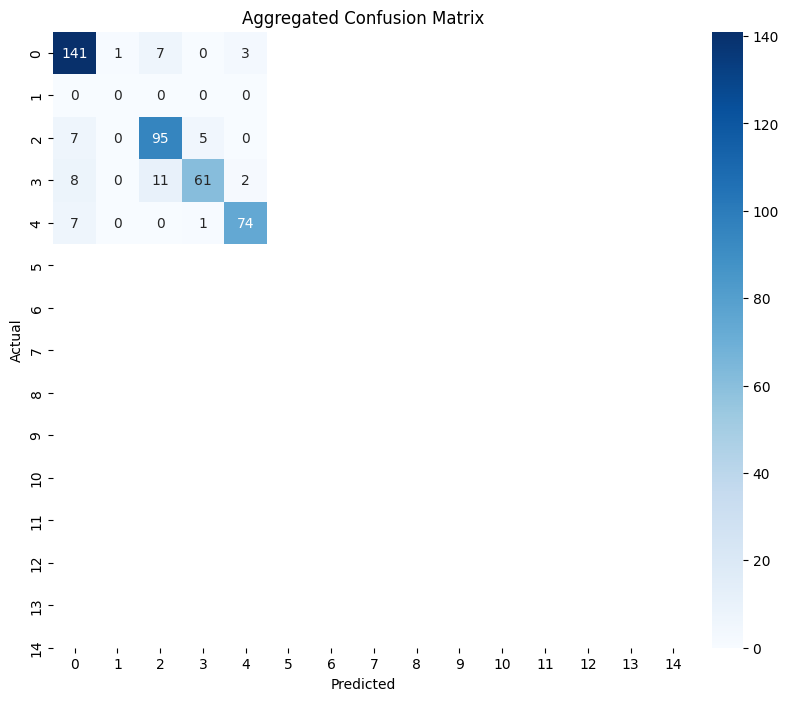

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, multilabel_confusion_matrix
import torch


def evaluate_multi_label(model, test_data, num_classes=None, plot_cm=True, top_k=2):
    """
    Evaluate multi-label classification model performance

    Args:
        model: The model to evaluate
        test_data: Test dataset
        num_classes: Number of classes
        plot_cm: Whether to plot confusion matrices
        top_k: Number of top predictions to consider
    Returns:
        Dictionary containing various evaluation metrics
    """
    batch_size = 32  # Increased batch size for efficiency

    test = Dataset(test_data)
    test_dataloader = torch.utils.data.DataLoader(test, batch_size=batch_size)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for test_input, test_label in test_dataloader:
            test_label = test_label.to(device)
            mask = test_input['attention_mask'].to(device)
            input_id = test_input['input_ids'].squeeze(1).to(device)

            output = model(input_id, mask)
            probs = output  # Assuming raw logits as output

            # Store probabilities and labels
            all_probs.append(probs.cpu())
            all_labels.append(test_label.cpu())

    # Concatenate all batches
    all_probs = torch.cat(all_probs, dim=0).numpy()
    all_labels = torch.cat(all_labels, dim=0).numpy()

    # Get top-k predictions
    top_k_preds = np.zeros_like(all_labels)
    for i in range(len(all_probs)):
        top_k_indices = np.argsort(all_probs[i])[-top_k:]
        top_k_preds[i, top_k_indices] = 1

    # Calculate metrics
    results = {
        'accuracy': accuracy_score(all_labels, top_k_preds),
        'micro_f1': f1_score(all_labels, top_k_preds, average='micro'),
        'macro_f1': f1_score(all_labels, top_k_preds, average='macro'),
        'micro_precision': precision_score(all_labels, top_k_preds, average='micro'),
        'macro_precision': precision_score(all_labels, top_k_preds, average='macro'),
        'micro_recall': recall_score(all_labels, top_k_preds, average='micro'),
        'macro_recall': recall_score(all_labels, top_k_preds, average='macro'),
    }

    # Print results
    print(f"Accuracy: {results['accuracy']:.4f}")
    print(f"Micro F1: {results['micro_f1']:.4f}")
    print(f"Macro F1: {results['macro_f1']:.4f}")
    print(f"Micro Precision: {results['micro_precision']:.4f}")
    print(f"Macro Precision: {results['macro_precision']:.4f}")
    print(f"Micro Recall: {results['micro_recall']:.4f}")
    print(f"Macro Recall: {results['macro_recall']:.4f}")

    # Confusion matrices
    if num_classes is not None:
        # Per-class confusion matrices
        mcm = multilabel_confusion_matrix(all_labels, top_k_preds)
        results['confusion_matrices'] = mcm

        if plot_cm:
            # Plot confusion matrix for each class
            fig, axes = plt.subplots(
                nrows=(num_classes+3)//4, ncols=4, figsize=(20, 5*((num_classes+3)//4)))
            axes = axes.flatten()

            for i in range(num_classes):
                sns.heatmap(mcm[i], annot=True, fmt='d',
                            cmap='Blues', ax=axes[i])
                axes[i].set_title(f'Class {i}')
                axes[i].set_xlabel('Predicted')
                axes[i].set_ylabel('Actual')

            # Hide unused subplots
            for j in range(i+1, len(axes)):
                axes[j].axis('off')

            plt.tight_layout()
            plt.show()

            # Plot aggregated confusion matrix
            agg_cm = confusion_matrix(all_labels.argmax(
                axis=1), top_k_preds.argmax(axis=1))
            plt.figure(figsize=(10, 8))
            sns.heatmap(agg_cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=range(num_classes),
                        yticklabels=range(num_classes))
            plt.xlabel('Predicted')
            plt.ylabel('Actual')
            plt.title('Aggregated Confusion Matrix')
            plt.show()

    return results


# Example usage
evaluation_results = evaluate_multi_label(
    model, df_test, num_classes=15, top_k=2)

In [19]:
import torch
import numpy as np


def predict_text(model, tokenizer, text, device=None, top_k=15):
    """
    Predict top-k classes for input text

    Args:
        model: Trained model
        tokenizer: Tokenizer for the model
        text: Input text to classify
        device: Device to use (cuda/cpu)
        top_k: Number of top predictions to return

    Returns:
        Tuple of (top class indices, top class probabilities, all probabilities)
    """
    # Set device
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Prepare input
    inputs = tokenizer(text,
                       padding='max_length',
                       max_length=128,
                       truncation=True,
                       return_tensors="pt")

    # Move to device
    input_ids = inputs['input_ids'].squeeze(1).to(device)
    attention_mask = inputs['attention_mask'].to(device)

    # Make prediction
    model.eval()
    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        probs = torch.sigmoid(outputs) if outputs.min(
        ) < 0 else outputs  # Apply sigmoid if logits

    # Convert to numpy
    probs = probs.cpu().numpy().flatten()

    # Get top-k predictions
    top_indices = np.argsort(probs)[-top_k:][::-1]  # Sort descending
    top_probs = probs[top_indices]

    return top_indices, top_probs, probs

# Example usage:
# tokenizer = AutoTokenizer.from_pretrained('your_model_name')
# model = YourModelClass()
# model.load_state_dict(torch.load('model_weights.pth'))


text = np.array(df_test['comment'])[0]
top_indices, top_probs, all_probs = predict_text(model, tokenizer, text)

print("Top predicted classes:")
for idx, prob in zip(top_indices, top_probs):
    print(f"Class {idx}: {prob:.4f}")

Top predicted classes:
Class 9: 0.8742
Class 11: 0.8338
Class 10: 0.1180
Class 6: 0.0763
Class 0: 0.0732
Class 3: 0.0699
Class 7: 0.0661
Class 14: 0.0660
Class 12: 0.0653
Class 1: 0.0600
Class 5: 0.0583
Class 13: 0.0566
Class 8: 0.0527
Class 4: 0.0429
Class 2: 0.0412


In [79]:
df_test.head(36)

,Unnamed: 0,class,comment,full_class,subclass,labels
605,170,3,The test sensitivity is 99%—rapid tests averag...,3.2,2,32
678,30,1,The fatality curve lacks the expected reportin...,1.4,4,14
1883,102,4,Peak ICU demand is 10K beds; triage protocols ...,4.2,2,42
1293,105,2,The model assumes lockdowns reduce R0 to 0.7; ...,2.2,2,22
581,146,3,The testing ramp-up’s effect is immediate—capa...,3.1,1,31
1476,77,1,The curve doesn't account for changes in death...,1.4,4,14
380,55,2,The effect of vaccination is too linear; real-...,2.2,2,22
128,128,2,The curve should reflect the contact tracing a...,2.3,3,23
1552,153,3,The model misplaces the 10-day gap between cas...,3.1,1,31
1900,9,1,The peak height suggests 100% susceptibility; ...,1.1,1,11
